# Example of the aitlas toolbox in the context of semantic segmentation

## Import the required packages

In [ ]:
from aitlas.datasets import SpaceNet6Dataset
from aitlas.utils import image_loader
from aitlas.models import DeepLabV3
from aitlas.transforms import MinMaxNormTranspose, ResizeToTensor

## Prepare the data

In [ ]:
dataset_config = {
    "orients": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SummaryData/SAR_orientations.txt",
    "num_folds": 10,
    "orients_output": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SummaryData/SAR_orientations.txt",
    "edge_width": 3,
    "contact_width": 9,
    "folds_dir": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/folds/"
}
dataset = SpaceNet6Dataset(dataset_config)
dataset.prepare

## Create the masks

In [ ]:
segmentation_directory = "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/segmentation/SAR-Intensity/"
edge_width = 3
contact_width = 9
gt_buildings_csv = "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SummaryData/SN6_Train_AOI_11_Rotterdam_Buildings.csv"
image_dir = "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SAR-Intensity/"
for image in os.listdir(image_dir):
    image_path = os.path.join(image_dir, image)
    process_image(image_path, segmentation_directory, edge_width, contact_width, gt_buildings_csv)

## Visualize images and masks

In [11]:
dataset_config = {
    "orients": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SummaryData/SAR_orientations.txt",
    "root_directory": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SAR-Intensity/",
    "segmentation_directory": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/segmentation/SAR-Intensity"
}
dataset = SpaceNet6Dataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

Total number of patches: 3401


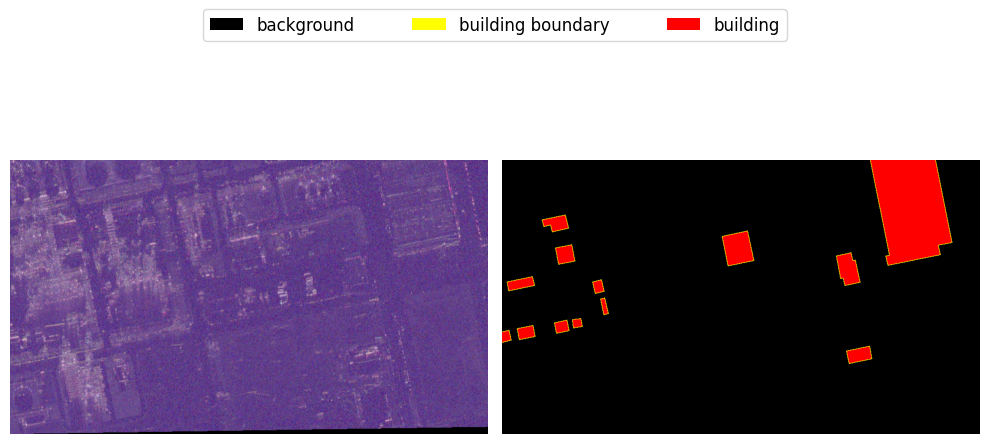

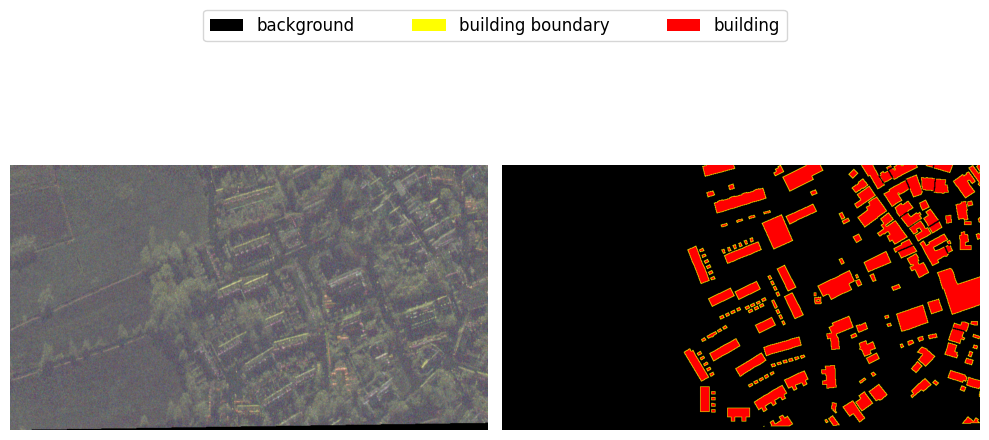

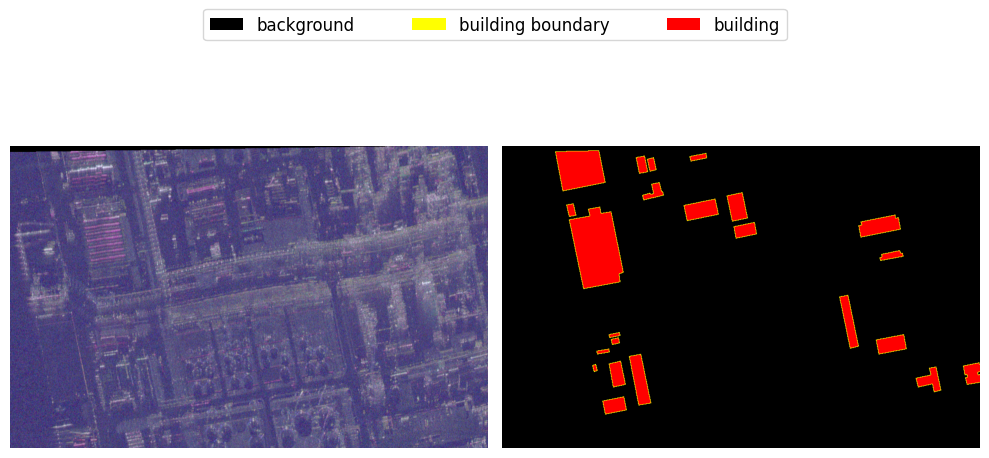

In [12]:
dataset.show_image(10)
dataset.show_image(100)
dataset.show_image(300);

In [5]:
dataset.data_distribution_table()

,Number of pixels
background,1.637240e+09
building boundary,2.788033e+07
building,1.729903e+08


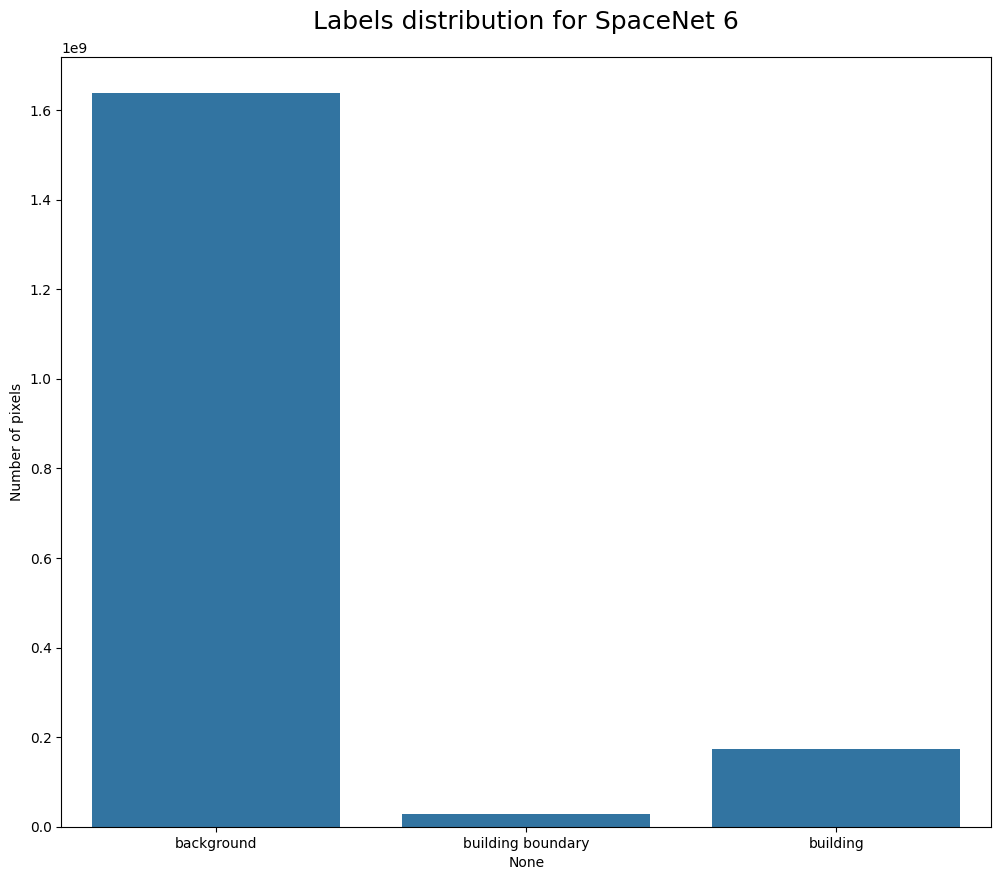

In [6]:
dataset.data_distribution_barchart();

## Load training data

In [4]:
train_dataset_config = {
    "batch_size": 16,
    "shuffle": True,
    "num_workers": 4,
    "orients": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SummaryData/SAR_orientations.txt",
    "root_directory": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/SAR-Intensity/",
    "segmentation_directory": "/home/dragik/data/spacenet6/train/AOI_11_Rotterdam/segmentation/SAR-Intensity",
    "transforms": ["aitlas.transforms.ResizeToTensor"],
    "target_transforms": ["aitlas.transforms.ResizePerChannelToTensor"]
}
train_dataset = SpaceNet6Dataset(train_dataset_config)

len(train_dataset)

3401

## Create the model

In [5]:
epochs = 10
model_directory = "/home/dragik/data/spacenet6/experiments"
model_config = {
    "num_classes": 3, 
    "learning_rate": 0.0001,
    "pretrained": True, 
    "threshold": 0.5,
    "metrics": ["iou"]
}

model = DeepLabV3(model_config)
model.prepare()

## Start the training

In [6]:
model.train_model(
    train_dataset=train_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id='1'
)

2025-12-01 08:29:35,754 INFO Starting training.
training: 100%|██████████| 213/213 [55:10<00:00, 15.54s/it]
2025-12-01 09:24:45,849 INFO epoch: 1, time: 3310, loss:  0.39168
testing on train set: 100%|██████████| 213/213 [54:59<00:00, 15.49s/it] 
2025-12-01 10:19:46,658 INFO IOU:0.7704999368083983, IOU mean:0.37792036452884137, IOU per Class:[0.87738125 0.         0.25637984]
training: 100%|██████████| 213/213 [53:51<00:00, 15.17s/it]
2025-12-01 11:13:38,382 INFO epoch: 2, time: 3232, loss:  0.20562
testing on train set: 100%|██████████| 213/213 [53:36<00:00, 15.10s/it] 
2025-12-01 12:07:14,845 INFO IOU:0.8570586578975594, IOU mean:0.44611783188374177, IOU per Class:[0.90743931 0.         0.43091419]
training: 100%|██████████| 213/213 [54:02<00:00, 15.22s/it]
2025-12-01 13:01:17,205 INFO epoch: 3, time: 3243, loss:  0.12449
testing on train set: 100%|██████████| 213/213 [55:00<00:00, 15.49s/it] 
2025-12-01 13:56:17,596 INFO IOU:0.8678053930097099, IOU mean:0.4614587323381085, IOU per C

0.056895482140546405

## Predictions

2025-12-02 07:48:33,205 INFO Loading checkpoint /home/dragik/data/spacenet6/experiments/checkpoint.pth.tar
2025-12-02 07:48:33,573 INFO Loaded checkpoint /home/dragik/data/spacenet6/experiments/checkpoint.pth.tar at epoch 11


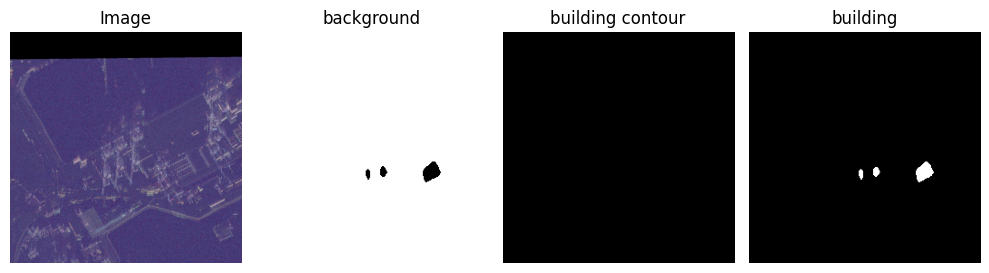

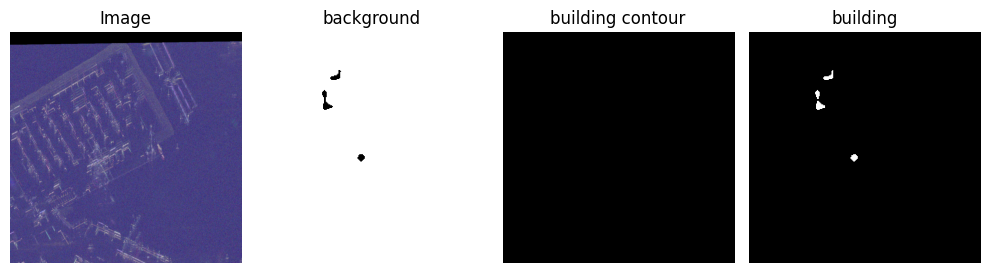

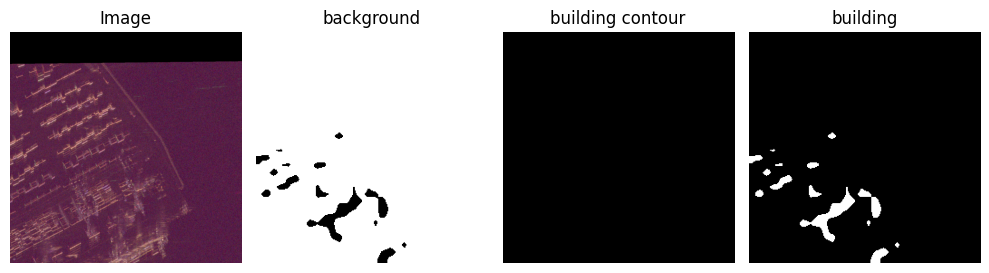

In [9]:
model_path = "/home/dragik/data/spacenet6/experiments/checkpoint.pth.tar"
labels = ["background","building contour","building"]
transform = ResizeToTensor()
model.load_model(model_path)

image = image_loader("/home/dragik/data/spacenet6/test_public/AOI_11_Rotterdam/SAR-Intensity/SN6_Test_Public_AOI_11_Rotterdam_SAR-Intensity_20190804111224_20190804111453_tile_8705.tif")
image = image[:,:,[0,3,1]]
img_min, img_max = image.min(), image.max()
image = (image - img_min) / (img_max - img_min + 1e-8)
fig = model.predict_masks(image, labels, transform)

image = image_loader("/home/dragik/data/spacenet6/test_public/AOI_11_Rotterdam/SAR-Intensity/SN6_Test_Public_AOI_11_Rotterdam_SAR-Intensity_20190822153558_20190822153835_tile_2553.tif")
image = image[:,:,[0,3,1]]
img_min, img_max = image.min(), image.max()
image = (image - img_min) / (img_max - img_min + 1e-8)
fig = model.predict_masks(image, labels, transform)

image = image_loader("/home/dragik/data/spacenet6/test_public/AOI_11_Rotterdam/SAR-Intensity/SN6_Test_Public_AOI_11_Rotterdam_SAR-Intensity_20190823124221_20190823124528_tile_9893.tif")
image = image[:,:,[0,3,1]]
img_min, img_max = image.min(), image.max()
image = (image - img_min) / (img_max - img_min + 1e-8)
fig = model.predict_masks(image, labels, transform)